In [56]:
!pip install torchinfo

In [57]:
import os
import sys
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
import zipfile
import shutil


In [58]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [60]:
zip_path = "/content/drive/MyDrive/wildlife.zip"

extraction_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extraction_path)

print("Image Dataset extracted successfully")

Image Dataset extracted successfully


In [61]:
df = pd.read_csv("/content/dataset/train_labels.csv")
df.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [62]:
source_dir = "dataset/train_features"

dest_dir = "dataset/organized_features"


classes = df.columns[1:]

for animal_class in classes:
    os.makedirs(os.path.join(dest_dir, animal_class), exist_ok=True)

animal_mapping = df.set_index('id').idxmax(axis=1)

print(f"Creating folders and sorting {len(animal_mapping)} images...")

# Iterate through the mapping and physically move the images
for img_id, animal_class in tqdm(animal_mapping.items(), total=len(animal_mapping)):

    src_path = os.path.join(source_dir, f"{img_id}.jpg")
    dst_path = os.path.join(dest_dir, animal_class, f"{img_id}.jpg")

    if os.path.exists(src_path):

        shutil.move(src_path, dst_path)

print(" Organized Classes Executed")

Creating folders and sorting 16488 images...


  0%|          | 0/16488 [00:00<?, ?it/s]

 Organized Classes Executed


In [63]:
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [64]:
transform = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

In [65]:
train_dir = os.path.join("dataset","organized_features")

print("Will read data from", train_dir)

Will read data from dataset/organized_features


In [66]:
dataset = datasets.ImageFolder(root=train_dir, transform=transform)

In [67]:
classes = os.listdir(train_dir)
print(f"Classes: {classes}")

Classes: ['hog', 'monkey_prosimian', 'civet_genet', 'leopard', 'antelope_duiker', 'rodent', 'blank', 'bird']


In [68]:
print("Tensor shape for one image:")
print(dataset[0][0].shape)

Tensor shape for one image:
torch.Size([3, 224, 224])


In [69]:
batch_size = 32
dataset_loader = DataLoader(dataset, batch_size=batch_size)

# Get one batch
first_batch = next(iter(dataset_loader))

print(f"Shape of one batch: {first_batch[0].shape}")
print(f"Shape of labels: {first_batch[1].shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])
Shape of labels: torch.Size([32])


# Preparing Our Data

Neural networks learn faster, more stably, and more accurately when the input features are centered around 0 and have a similar scale.

In [70]:
def get_mean_std(loader):
    """Computes the mean and standard deviation of image data.

    Input: a `DataLoader` producing tensors of shape [batch_size, channels, pixels_x, pixels_y]
    Output: the mean of each channel as a tensor, the standard deviation of each channel as a tensor
            formatted as a tuple (means[channels], std[channels])"""

    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in tqdm(loader, desc="Computing mean and std", leave=False):
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2) ** 0.5

    return mean, std

In [71]:
mean, std = get_mean_std(dataset_loader)

print(f"Mean: {mean}")
print(f"Standard deviation: {std}")

Computing mean and std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([0.4788, 0.4925, 0.4833])
Standard deviation: tensor([0.2541, 0.2470, 0.2501])


In [72]:
transform_norm = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

In [73]:
norm_dataset = datasets.ImageFolder(root= train_dir, transform=transform_norm)

norm_loader = DataLoader(norm_dataset, batch_size=batch_size)

In [74]:
norm_mean, norm_std = get_mean_std(norm_loader)

print(f"Mean: {norm_mean}")
print(f"Standard deviation: {norm_std}")

Computing mean and std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([-2.2570e-07, -7.9987e-07, -1.4907e-07])
Standard deviation: tensor([1.0000, 1.0000, 1.0000])


# Train and Validation Split

In [75]:
train_dataset, val_dataset = random_split(norm_dataset, [0.8, 0.2])

length_train = len(train_dataset)
length_val = len(val_dataset)
length_dataset = len(norm_dataset)
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 80.0% of full data
Validation data is 20.0% of full data


In [76]:
# Access the underlying original dataset through the Subset wrapper
print("The exact list order:")
print(train_dataset.dataset.classes)

print("\nThe dictionary mapping (Class Name : Index Number):")
print(train_dataset.dataset.class_to_idx)

The exact list order:
['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']

The dictionary mapping (Class Name : Index Number):
{'antelope_duiker': 0, 'bird': 1, 'blank': 2, 'civet_genet': 3, 'hog': 4, 'leopard': 5, 'monkey_prosimian': 6, 'rodent': 7}


In [77]:
idx_to_class = {v: k for k, v in train_dataset.dataset.class_to_idx.items()}

print("The reversed dictionary mapping (Index Number : Class Name):")
print(idx_to_class)

The reversed dictionary mapping (Index Number : Class Name):
{0: 'antelope_duiker', 1: 'bird', 2: 'blank', 3: 'civet_genet', 4: 'hog', 5: 'leopard', 6: 'monkey_prosimian', 7: 'rodent'}


In [78]:
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)

In [79]:
test_batch = next(iter(dataset_loader))[0]
batch_shape = test_batch.shape

# Create the model summary
summary(model, batch_shape)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 1000]                --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          4,096
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│ 

In [80]:
for params in model.parameters():
    params.requires_grad = False

In [81]:
model = model.to(device)
test_batch = test_batch.to(device)

model_test_out = model(test_batch)

print("Output shape:", model_test_out.shape)

Output shape: torch.Size([32, 1000])


In [82]:
list(model.named_modules())[-1]

('fc', Linear(in_features=2048, out_features=1000, bias=True))

In [83]:
in_features = model.fc.in_features
in_features

2048

In [84]:
custom_classifier = torch.nn.Sequential()

In [85]:
cl_layer_1 = torch.nn.Linear(in_features=in_features, out_features=500)

custom_classifier.append(cl_layer_1)

Sequential(
  (0): Linear(in_features=2048, out_features=500, bias=True)
)

In [86]:
custom_classifier.append(torch.nn.ReLU())
custom_classifier.append(torch.nn.Dropout())

Sequential(
  (0): Linear(in_features=2048, out_features=500, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
)

In [87]:
output_layer = torch.nn.Linear(in_features=500, out_features=8)

# Add the layer to our classifier
custom_classifier.append(output_layer)

Sequential(
  (0): Linear(in_features=2048, out_features=500, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=500, out_features=8, bias=True)
)

In [88]:
model.fc = custom_classifier

In [89]:
summary(model, batch_shape)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 8]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (4,096)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]   

# Train Test Distribution

In [90]:
def class_counts(dataset):
    c = Counter(x[1] for x in tqdm(dataset))

    idx_to_class = {v: k for k, v in dataset.dataset.class_to_idx.items()}

    return pd.Series({cat: c[idx] for idx, cat in idx_to_class.items()})

In [91]:
train_class_distributions = class_counts(train_dataset)

train_class_distributions

  0%|          | 0/13191 [00:00<?, ?it/s]

,0
antelope_duiker,1966
bird,1290
blank,1770
civet_genet,1944
hog,778
leopard,1823
monkey_prosimian,1989
rodent,1631


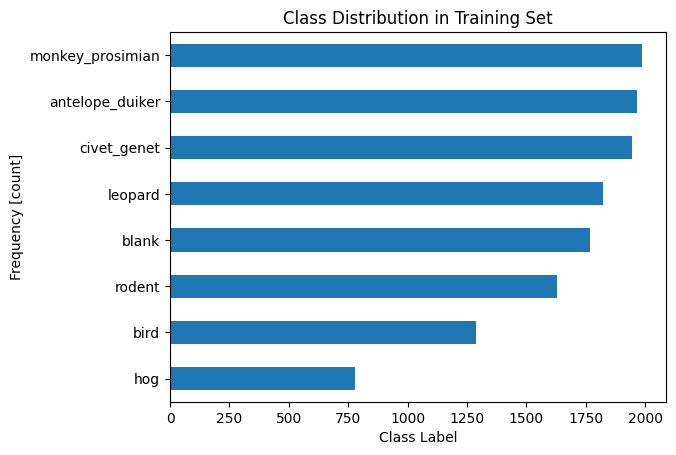

In [92]:
train_class_distributions.sort_values().plot(kind="barh")

plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Training Set");

In [93]:
total_samples = sum(train_class_distributions)
no_of_classes = len(train_class_distributions)

weights_list = [total_samples / (no_of_classes * value) for value in train_class_distributions.values]

class_weights = torch.tensor(weights_list, dtype=torch.float32)

print(class_weights)


tensor([0.8387, 1.2782, 0.9316, 0.8482, 2.1194, 0.9045, 0.8290, 1.0110])


In [94]:
validation_class_distributions = class_counts(val_dataset)

print(validation_class_distributions)

  0%|          | 0/3297 [00:00<?, ?it/s]

antelope_duiker     508
bird                351
blank               443
civet_genet         479
hog                 200
leopard             431
monkey_prosimian    503
rodent              382
dtype: int64


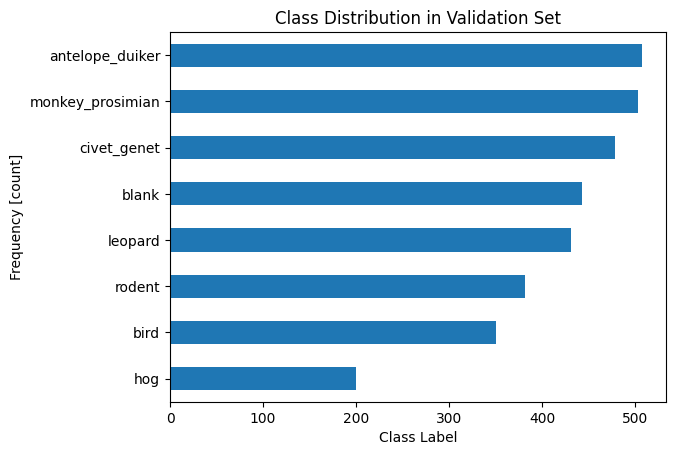

In [95]:
validation_class_distributions.sort_values().plot(kind="barh")


plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Validation Set");

In [96]:
batch_size = 32

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=batch_size)

single_batch = next(iter(train_loader))[0]
print(f"Shape of one batch: {single_batch.shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])


# Training The Model

In [97]:
from training import predict, train

In [98]:
class_weights = class_weights.to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)


model = model.to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [99]:
train(model,optimizer,loss_fn,train_loader,val_loader,epochs=5,device=device)

Training:   0%|          | 0/413 [00:00<?, ?it/s]

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 1.35, Validation Loss: 0.99, Validation accuracy = 0.65


Training:   0%|          | 0/413 [00:00<?, ?it/s]

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch: 4, Training Loss: 0.78, Validation Loss: 0.72, Validation accuracy = 0.74


Training:   0%|          | 0/413 [00:00<?, ?it/s]

Scoring:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch: 5, Training Loss: 0.72, Validation Loss: 0.70, Validation accuracy = 0.75


In [100]:
probabilities = predict(model, val_loader, device)
predictions = torch.argmax(probabilities,dim=1)

Predicting:   0%|          | 0/104 [00:00<?, ?it/s]

In [101]:
targets = []

for _, labels in tqdm(val_loader):
    targets.extend(labels.tolist())

  0%|          | 0/104 [00:00<?, ?it/s]

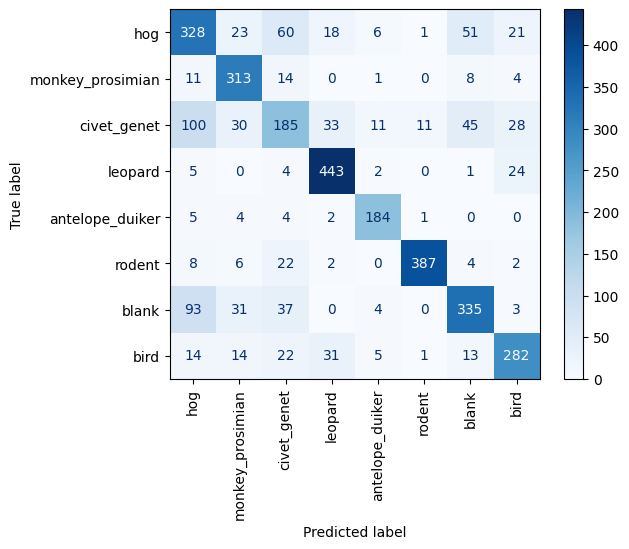

In [102]:
cm = confusion_matrix(targets, predictions.cpu())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.show();

# ID Mapping CSV

In [103]:
# The root folder for your data
dataset_root = "dataset"

# The path to your CSV file
csv_location = os.path.join(dataset_root, "test_features.csv")

# Read the CSV
df_ids = pd.read_csv(csv_location)
df_ids.head()

,id,filepath,site
0,ZJ016488,test_features/ZJ016488.jpg,S0082
1,ZJ016489,test_features/ZJ016489.jpg,S0040
2,ZJ016490,test_features/ZJ016490.jpg,S0040
3,ZJ016491,test_features/ZJ016491.jpg,S0041
4,ZJ016492,test_features/ZJ016492.jpg,S0040


In [104]:
model.to(device)


def file_to_confidence(file_path, image_id):
    image = PIL.Image.open(file_path)
    transformed = transform_norm(image)
    unsqueezed = transformed.unsqueeze(0)
    image_cuda = unsqueezed.to(device)

    model.eval()
    with torch.no_grad():
        model_raw = model(image_cuda)
        confidence = torch.nn.functional.softmax(model_raw, dim=1)

    conf_df = pd.DataFrame(confidence.tolist())
    conf_df.columns = dataset.classes
    conf_df.index = [image_id]

    return conf_df

In [105]:
print(df_ids.columns)

Index(['id', 'filepath', 'site'], dtype='object')


In [106]:
# 1. Filter out the CSV (if it's somehow still in there)
df_images_only = df_ids[~df_ids['id'].str.endswith('.csv')]

# 2. Run the loop using the correct base directory and row.filepath
confidence_df = pd.concat([
    # We join "dataset" with "test_features/ZJXXXXXX.jpg"
    file_to_confidence(os.path.join(dataset_root, row.filepath), row.id)
    for row in df_images_only.itertuples()
])

In [107]:
confidence_df.to_csv("submission3.csv")

In [108]:
confidence_df.head()

,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
ZJ016488,0.070152,0.006411,0.224676,0.613936,0.007227,0.009895,0.010813,0.056890
ZJ016489,0.723212,0.005266,0.005006,0.000540,0.263916,0.000694,0.001220,0.000147
ZJ016490,0.593890,0.003204,0.201108,0.163079,0.026167,0.000908,0.002196,0.009448
ZJ016491,0.000057,0.000004,0.000435,0.000149,0.000744,0.998572,0.000008,0.000030
ZJ016492,0.279994,0.107600,0.081249,0.017003,0.048740,0.001083,0.400717,0.063615


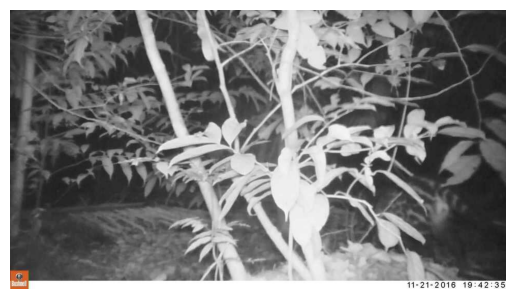

In [109]:
image_ext = os.path.join("dataset","test_features","ZJ016488.jpg")

image = PIL.Image.open(image_ext)

plt.imshow(image)
plt.axis("off");

In [110]:
torch.save(model.state_dict(), "wild_life_deepnet4.pth")